# **Exploratory Data Analysis (EDA) on Long-Term VM Candidates**

## **Notebook Objective**
This notebook aims to perform **Exploratory Data Analysis (EDA)** on the extracted **long-term Virtual Machine (VM) candidates** to understand the distribution, rate, and percentage of usage of the `vm_category` column present in the `vmtable.csv` dataset.

## **Dataset Source**
The dataset `vmtable.csv` has been provided by the data provider and is available in their **GitHub repository**.

## **Key Analysis Steps**
- Load and explore the dataset.
- Perform data cleaning and preprocessing if necessary.
- Analyze the distribution of `vm_category`.
- Compute and visualize the rate and percentage of each category.
- Identify patterns or trends in long-term VM usage.

## **Tools & Libraries Used**
- **Polars** for **fast** read and data manipulation over large data using `df.lazy()`.
- **Matplotlib & Seaborn** for visualization.
- **NumPy** for numerical computations.

## **Expected Outcome**
This analysis will help in understanding how different VM categories are utilized over the long term, providing insights for potential optimizations or forecasting.

---

📌 **Note:** If any additional data preprocessing or specific analysis is required, modifications can be made accordingly.

---

### **Dataset Characteristics**

<center>

$\#$ public dataset | Year of Azure VM workload collection | Duration | Total #VMs | Time-resolution/epoch | Dataset size
---|:---:|:-----:|:---:|:---:|:---:
#1 [MS Azure cloud VM CPU Usage](https://github.com/amcs1729/Predicting-cloud-CPU-usage-on-Azure-data/blob/master/README.md)  | [Jan 2017](https://github.com/amcs1729/Predicting-cloud-CPU-usage-on-Azure-data?tab=readme-ov-file) | 30 consecutive days | 1 | 5-minute VM CPU utilization readings |  633KB (csv) [1 file]
#2 [AzurePublicDatasetV1](https://github.com/Azure/AzurePublicDataset/blob/master/AzurePublicDatasetV1.md) | [2017](https://github.com/Azure/AzurePublicDataset/tree/master) | maximum 30 consecutive days | 2,013,767 (~2M) | 5-minute VM CPU utilization readings (encrypted) |  117GB (78.5GB compressed) [128 files]
#3 [AzurePublicDatasetV2](https://github.com/Azure/AzurePublicDataset/blob/master/AzurePublicDatasetV2.md)  | [2019](https://github.com/Azure/AzurePublicDataset/tree/master) | maximum 30 consecutive days | 2,695,548 (~2.6M) | 5-minute VM CPU utilization readings (encrypted) |  235GB (156GB compressed) [198 files]

</center>

---


In [ ]:
import polars as pl
import glob
import os
import re

#import warnings
#warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
import pandas as pd
pd.__version__    #'2.0.3'

'2.1.4'

In [ ]:
#!pip install pandas==2.1.4

In [ ]:
def sanitize_filename(vmid):
    return re.sub(r'[<>:"/\\|?*]', '_', vmid)

In [ ]:
%%time
# Define output directory
output_dir = "/home/mehryar/interested_vmid_list_V2"
os.makedirs(output_dir, exist_ok=True)  # Create the output directory if it doesn't exist

# Search for all csv.gz files in the folder
path = "/home/mehryar/vm_cpu_readings_V2/data/*.csv.gz"
files = glob.glob(path)

lazy_dfs = []

column_names = ['timestamp', 'vmid', 'mincpu', 'maxcpu', 'avgcpu']

for file in files:
    df = pl.read_csv(file, has_header=False, new_columns=column_names)
    lazy_df = df.lazy()
    lazy_dfs.append(lazy_df)
    print(f'Read: {file}')

# Combine all dataframes into a single dataframe
combined_lazy_df = pl.concat(lazy_dfs)

Read: /home/mehryar/vm_cpu_readings_V2/data/vm_cpu_readings-file-164-of-195.csv.gz
Read: /home/mehryar/vm_cpu_readings_V2/data/vm_cpu_readings-file-62-of-195.csv.gz
Read: /home/mehryar/vm_cpu_readings_V2/data/vm_cpu_readings-file-86-of-195.csv.gz
Read: /home/mehryar/vm_cpu_readings_V2/data/vm_cpu_readings-file-41-of-195.csv.gz
Read: /home/mehryar/vm_cpu_readings_V2/data/vm_cpu_readings-file-56-of-195.csv.gz
Read: /home/mehryar/vm_cpu_readings_V2/data/vm_cpu_readings-file-180-of-195.csv.gz
Read: /home/mehryar/vm_cpu_readings_V2/data/vm_cpu_readings-file-33-of-195.csv.gz
Read: /home/mehryar/vm_cpu_readings_V2/data/vm_cpu_readings-file-78-of-195.csv.gz
Read: /home/mehryar/vm_cpu_readings_V2/data/vm_cpu_readings-file-80-of-195.csv.gz
Read: /home/mehryar/vm_cpu_readings_V2/data/vm_cpu_readings-file-21-of-195.csv.gz
Read: /home/mehryar/vm_cpu_readings_V2/data/vm_cpu_readings-file-124-of-195.csv.gz
Read: /home/mehryar/vm_cpu_readings_V2/data/vm_cpu_readings-file-101-of-195.csv.gz
Read: /home/

In [ ]:
#print("Combined Columns:", combined_lazy_df.columns)
print("Combined Columns:", combined_lazy_df.collect_schema().names())

Combined Columns: ['timestamp', 'vmid', 'mincpu', 'maxcpu', 'avgcpu']


In [ ]:
%%time
new_column_names = column_names

if len(combined_lazy_df.collect_schema().names()) == len(new_column_names):
    combined_lazy_df = combined_lazy_df.rename(
        {old_name: new_name for old_name, new_name in zip(combined_lazy_df.collect_schema().names(), new_column_names)}
    )

if all(col in combined_lazy_df.collect_schema().names() for col in ['timestamp', 'vmid', 'mincpu', 'maxcpu', 'avgcpu']):
    # Get the count of rows for each vmid
    vmid_counts = combined_lazy_df.group_by("vmid").count().collect()
    # print(vmid_counts)
    # Filter vmids with more than 8064 rows
    #valid_vmids = vmid_counts.filter(pl.col("count") > 88)["vmid"].to_list()      #20*288
    valid_vmids = vmid_counts.filter(pl.col("count") >= 8352)["vmid"].to_list()      #29*288=8352  pl.col("count") ---> pl.col("len")
    print("Unique VMIDs contain 8352 rows:", len(valid_vmids))                     #179,393

    # Convert the valid_vmids list to a DataFrame
    valid_vmids_df = pl.DataFrame({"vmid": valid_vmids})
    # Define the name of the output file
    output_file = os.path.join(output_dir, "valid_vmids_V2.csv")
    # Save DataFrame as CSV
    valid_vmids_df.write_csv(output_file)

    print(f"Valid VMIDs have been saved to: {output_file}")

<timed exec>:10: DeprecationWarning: `LazyGroupBy.count` is deprecated. It has been renamed to `len`.


Unique VMIDs contain 8352 rows: 179393
Valid VMIDs have been saved to: /home/mehryar/interested_vmid_list_V2/valid_vmids_V2.csv
CPU times: user 27min 29s, sys: 29min 42s, total: 57min 11s
Wall time: 3min 13s


In [ ]:
valid_vmids_df

vmid
str
"""7L8kG+LIKrPhS8fsEaz02zWqn45sb2…"
"""l1ISKK3c5nlRvQKo5cWYsv+sridwGW…"
"""uZthjm8/wCz5sn9fr6Cf0hl/+IOKt1…"
"""ORsf4/RZOvBQ+1K6fO6sLjT/ARyuXI…"
"""uaMivAdCQzfD1Uh8Ng8kVO/6seXV7o…"
…
"""J67GxLSnxSlUTISyEM+/HfMg0f5vvM…"
"""0EqBhOYipAa2WPZE/g+5xTjuzixuET…"
"""+6hVfjDJn7XwvbcUGToi6kbtybCiPE…"


In [ ]:
# 1. Load the valid_vmids.csv file
valid_vmids_df = pl.read_csv(os.path.join(output_dir, "/home/mehryar/interested_vmid_list_V2/valid_vmids_V2.csv"))
valid_vmids_df

vmid
str
"""7L8kG+LIKrPhS8fsEaz02zWqn45sb2…"
"""l1ISKK3c5nlRvQKo5cWYsv+sridwGW…"
"""uZthjm8/wCz5sn9fr6Cf0hl/+IOKt1…"
"""ORsf4/RZOvBQ+1K6fO6sLjT/ARyuXI…"
"""uaMivAdCQzfD1Uh8Ng8kVO/6seXV7o…"
…
"""J67GxLSnxSlUTISyEM+/HfMg0f5vvM…"
"""0EqBhOYipAa2WPZE/g+5xTjuzixuET…"
"""+6hVfjDJn7XwvbcUGToi6kbtybCiPE…"


In [ ]:
%%time

# 1. Load the valid_vmids.csv file
valid_vmids_df = pl.read_csv(os.path.join(output_dir, "/home/mehryar/interested_vmid_list_V2/valid_vmids_V2.csv"))

# 2. Load the vmtable.csv.gz file
data_path = '/home/mehryar/vm_cpu_readings_V2/misc/vmtable.csv.gz'
headers = ['vmid', 'subscriptionid', 'deploymentid', 'vmcreated', 'vmdeleted', 'maxcpu', 'avgcpu', 'p95maxcpu',
           'vmcategory', 'vmcorecountbucket', 'vmmemorybucket']

# Specify dtypes
dtypes = {
    'vmid': pl.Utf8,
    'subscriptionid': pl.Utf8,
    'deploymentid': pl.Utf8,
    'vmcreated': pl.Int64,
    'vmdeleted': pl.Int64,
    'maxcpu': pl.Float64,
    'avgcpu': pl.Float64,
    'p95maxcpu': pl.Float64,
    'vmcategory': pl.Utf8,
    'vmcorecountbucket': pl.Int64,
    'vmmemorybucket': pl.Int64
}

vmtable_df = pl.read_csv(
    data_path,
    has_header=False,
    new_columns=headers,
    dtypes=dtypes,
    ignore_errors=True,
    null_values=['>24'],
    try_parse_dates=True
)

# 3. Combine the data and create a new CSV file
trace_dataframe = (valid_vmids_df
             .join(vmtable_df.select(vmtable_df.columns), on='vmid', how='left')
             .sort('vmid'))

# Save the result as a CSV file
result_csv_path = os.path.join(output_dir, "vmtable_filtered_V2.csv")
trace_dataframe.write_csv(result_csv_path)
print(f"Results saved to: {result_csv_path}")


<timed exec>:24: DeprecationWarning: The argument `dtypes` for `read_csv` is deprecated. It has been renamed to `schema_overrides`.


Results saved to: /home/mehryar/interested_vmid_list_V2/vmtable_filtered_V2.csv
CPU times: user 11.2 s, sys: 2.85 s, total: 14.1 s
Wall time: 3.8 s


In [ ]:
vmtable_df

vmid,subscriptionid,deploymentid,vmcreated,vmdeleted,maxcpu,avgcpu,p95maxcpu,vmcategory,vmcorecountbucket,vmmemorybucket
str,str,str,i64,i64,f64,f64,f64,str,i64,i64
"""71fJw0x+SDRdAxKPwLyHZhTgQpYw2a…","""GB6uQC1NSArW5n+TtOybL7GQ1yByju…","""2sh/ZjaYdfpslv4iYBfNzFe4rs982k…",558300,1673700,91.776885,0.728879,20.75963,"""Delay-insensitive""",8,32
"""rKggHO/04j31UFy65mDTwtjdMQL/G0…","""ub4ty8ygwOECrIz7eaZ/9hDwnCsERv…","""+ZraIDUNaWYDZMBiBtZm7xSjr+j3zc…",424500,425400,37.879261,3.325358,37.879261,"""Unknown""",4,32
"""YrR8gPtBmfNaOdnNEW5If1SdTqQgGQ…","""9LrdYRcUfGbmL2fFfLR/JUg2OTkjGR…","""GEyIElfPSFupze8T+T1niQMepeqG88…",1133100,1133700,0.304368,0.220553,0.304368,"""Unknown""",4,32
"""xzQ++JF1UAkh70CDhmzkiOo+DQn+E2…","""0XnZZ8sMN5HY+Yg+0dykYB5oenlgsr…","""7aCQS6fPUw9rwCPiqvghk/WCEbMV3K…",0,2591400,98.573424,30.340054,98.212503,"""Interactive""",2,4
"""vZEivnhabRmImDr+JqKqZnpIM3Wxty…","""HUGaZ+piPP4eHjycCBki2yq0raJywd…","""/s/D5VtTQDxyS6wq7N/VQAMczx61Ny…",228300,229800,82.581449,13.876299,82.581449,"""Unknown""",2,4
…,…,…,…,…,…,…,…,…,…,…
"""CfZn37rcUvC4sVjWik6yIutOzNfno3…","""5zIKLXAWdyG8bQWPX+g0Zc4RjQlOYj…","""sB0KxCqfKVBclkgO327x9TDml4StRt…",141300,145200,95.902013,76.232801,95.902013,"""Unknown""",4,32
"""D5jsQPZSlO+KakH/yp7bPV5hrKPhyx…","""HD4yDQaGa1Yah7WxdgJ6vXIS2/ssrc…","""dVoT1JKlL3DDuEvSOLYeDW/HAuNR4X…",0,2591400,94.095362,5.845202,11.260807,"""Delay-insensitive""",2,4
"""FP9Lf4/jjWgWl9HS80x1NoeFwOPhLQ…","""1wYls1fw1ahqoRuYgqTwW1CWwFCA+G…","""H7sClR+x5JuEla7XAQrY+ndhsycwQg…",1744800,1802700,96.197271,12.361066,88.992556,"""Unknown""",2,4


In [ ]:
vmtable_df.columns

['vmid',
 'subscriptionid',
 'deploymentid',
 'vmcreated',
 'vmdeleted',
 'maxcpu',
 'avgcpu',
 'p95maxcpu',
 'vmcategory',
 'vmcorecountbucket',
 'vmmemorybucket']

In [ ]:
(valid_vmids_df.shape[0]/vmtable_df.shape[0])*100

6.655158802588565

In [ ]:
(179393/2695548 )*100

6.655158802588565

In [ ]:
trace_dataframe

vmid,subscriptionid,deploymentid,vmcreated,vmdeleted,maxcpu,avgcpu,p95maxcpu,vmcategory,vmcorecountbucket,vmmemorybucket
str,str,str,i64,i64,f64,f64,f64,str,i64,i64
"""++18Ccmd2vYdt+zkc4Vc+lVo6REGcz…","""y/fI3Ill4HNMGtw2nbxlrai7rG7Pnp…","""j/avq6PE8u5DUi7P1oFl4lx7sOkCz9…",0,2591400,97.942863,23.765894,43.13437,"""Interactive""",4,8
"""++5+Dee4aPwvcaQHkPeVX4B3FAw5Bf…","""/aibrUZSdNAt/qzLUUvNYhK7DNUjQn…","""/0qy4/DoEG+HTQGroVSKPsrxOOcU7c…",0,2591400,96.347902,4.089595,11.276353,"""Delay-insensitive""",2,2
"""++5Ra5p5WFjoMtqyBzdyW4CtmDwlVJ…","""uG3yTFAy9zWMH6AHH+V/uaOb8UG4Ol…","""vZQik7urGZi0M8NJiOWOPhJzXT5Eur…",0,2591400,93.475743,3.163925,9.558935,"""Delay-insensitive""",2,2
"""++5ojZdnSbCBK2nAfqIoPMPVgNA2Gh…","""50Gfw/9+WojXTAmLaE0bnXm+/Nik4z…","""uhiBQx70piEC9APL/q1iiyyd34zqTi…",0,2591400,84.085084,2.187282,8.78861,"""Delay-insensitive""",2,4
"""++CkHE7ieswCc1/3x1Ss+OggoyCCAX…","""pERxfXtbbsMIRNVCQznro2qKkDug6K…","""ljMoErA/leExJ0pN96tTDPfuX6/N77…",0,2591400,98.865012,10.948142,95.80754,"""Interactive""",8,32
…,…,…,…,…,…,…,…,…,…,…
"""zzsyW6EbYbp1gJIeKZ4wwbGuaGtYQ7…","""fBlM5dUJFT9GgPevHoP3RW2h7PeBpD…","""SnoRUvJMiXU9Oa2+y4Wc96pimt+myc…",0,2591400,92.05602,51.115277,74.787636,"""Delay-insensitive""",2,4
"""zzvN304gT9cB6libBGmu7Vxm7O0L6w…","""dZicRxSsj49MaFhtMt88SLEamULu1h…","""ZI8BNoCcZlNMqYucv2Z/4+bjmqJHU0…",0,2591400,89.246552,7.857581,53.337363,"""Delay-insensitive""",8,32
"""zzvULvz7Zq7tRiC8DzmOJ1aJJ4o8JF…","""+qvP95TnZH/krjwDibsFWpCk3DjpkH…","""dMgC9dZi2njNEnmb/+Qj+u9mktRLeW…",0,2591400,96.23001,5.570202,11.008119,"""Delay-insensitive""",2,4


In [ ]:
data_path = '/home/mehryar/interested_vmid_list_V2/vmtable_filtered_V2.csv'
#data_path = 'https://azurecloudpublicdataset2.z19.web.core.windows.net/azurepublicdatasetv2/trace_data/vmtable/vmtable.csv.gz'
#data_path  = 'https://azurepublicdatasettraces.blob.core.windows.net/azurepublicdatasetv2/trace_data/vmtable/vmtable.csv.gz'

headers=['vmid','subscriptionid','deploymentid','vmcreated', 'vmdeleted', 'maxcpu', 'avgcpu', 'p95maxcpu', 'vmcategory', 'vmcorecountbucket', 'vmmemorybucket']
trace_dataframe = pd.read_csv(data_path, header=None, index_col=False,names=headers,delimiter=',',low_memory=False, skiprows=1)
trace_dataframe

,vmid,subscriptionid,deploymentid,vmcreated,vmdeleted,maxcpu,avgcpu,p95maxcpu,vmcategory,vmcorecountbucket,vmmemorybucket
0,++18Ccmd2vYdt+zkc4Vc+lVo6REGczrBrjnfj0MfUJ7gUl...,y/fI3Ill4HNMGtw2nbxlrai7rG7PnpqM8PaqtuUQR2KpgH...,j/avq6PE8u5DUi7P1oFl4lx7sOkCz9CF2svzsdRqJrp0C2...,0,2591400,97.942863,23.765894,43.134370,Interactive,4.0,8.0
1,++5+Dee4aPwvcaQHkPeVX4B3FAw5Bf6DheDRz0/mYuKmPt...,/aibrUZSdNAt/qzLUUvNYhK7DNUjQnMzivMPUHVI67UuCv...,/0qy4/DoEG+HTQGroVSKPsrxOOcU7cmLz5ZudYk8w9R8Qm...,0,2591400,96.347902,4.089595,11.276353,Delay-insensitive,2.0,2.0
2,++5Ra5p5WFjoMtqyBzdyW4CtmDwlVJBwqeeYKPftWyhM08...,uG3yTFAy9zWMH6AHH+V/uaOb8UG4Olss7NzgWiWkecgkxu...,vZQik7urGZi0M8NJiOWOPhJzXT5Eur+FqfQIOq0j5bwVtq...,0,2591400,93.475743,3.163925,9.558935,Delay-insensitive,2.0,2.0
3,++5ojZdnSbCBK2nAfqIoPMPVgNA2GhtuXh42Pq1C7tie+s...,50Gfw/9+WojXTAmLaE0bnXm+/Nik4zJ8oaQgvGRvi/w8sr...,uhiBQx70piEC9APL/q1iiyyd34zqTi8HI74auFZnn0c9xs...,0,2591400,84.085084,2.187282,8.788610,Delay-insensitive,2.0,4.0
4,++CkHE7ieswCc1/3x1Ss+OggoyCCAXiqt6NejLhn0gv+1W...,pERxfXtbbsMIRNVCQznro2qKkDug6KE1rQeGiM6eO8bdzy...,ljMoErA/leExJ0pN96tTDPfuX6/N77YXl3JmBW0Y4mHoF4...,0,2591400,98.865012,10.948142,95.807540,Interactive,8.0,32.0
...,...,...,...,...,...,...,...,...,...,...,...
179388,zzsyW6EbYbp1gJIeKZ4wwbGuaGtYQ73N9BOkdkvDYkLCiE...,fBlM5dUJFT9GgPevHoP3RW2h7PeBpDDTcxP1NE+esRmoKt...,SnoRUvJMiXU9Oa2+y4Wc96pimt+myc04uOc0F8otCoh0Wf...,0,2591400,92.056020,51.115277,74.787636,Delay-insensitive,2.0,4.0
179389,zzvN304gT9cB6libBGmu7Vxm7O0L6wHQEDiTK/nGA2lOMZ...,dZicRxSsj49MaFhtMt88SLEamULu1hP1ABfIbAWKjcp1+4...,ZI8BNoCcZlNMqYucv2Z/4+bjmqJHU02D+VZwn6e/s/CfV3...,0,2591400,89.246552,7.857581,53.337363,Delay-insensitive,8.0,32.0
179390,zzvULvz7Zq7tRiC8DzmOJ1aJJ4o8JFEED/fBQhw477PaN1...,+qvP95TnZH/krjwDibsFWpCk3DjpkHZl5pUASwYWXU1RD8...,dMgC9dZi2njNEnmb/+Qj+u9mktRLeWm3b49WsR/K3ZCJzx...,0,2591400,96.230010,5.570202,11.008119,Delay-insensitive,2.0,4.0
179391,zzxNHmLHVFw5anhaAFJMFIVfDmmMPmWjgyeYpE8W34fq0Y...,xzq9fgPBJNfDip3yythzGOExfNRjfekY6Coi4iaayOfnHc...,49ebPCA1DSpqzWYYWPSevuVrSK0uGyWasCLP3oFmvUV3Xn...,0,2591400,98.729194,1.763345,97.842402,Delay-insensitive,8.0,32.0


In [ ]:
print(trace_dataframe.shape)

(179393, 11)


In [ ]:
type(trace_dataframe)

pandas.core.frame.DataFrame

In [ ]:
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
%matplotlib inline

data_path = '/home/mehryar/interested_vmid_list_V2/vmtable_filtered_V2.csv'
#data_path = 'https://azurecloudpublicdataset2.z19.web.core.windows.net/azurepublicdatasetv2/trace_data/vmtable/vmtable.csv.gz'
#data_path  = 'https://azurepublicdatasettraces.blob.core.windows.net/azurepublicdatasetv2/trace_data/vmtable/vmtable.csv.gz'

headers=['vmid','subscriptionid','deploymentid','vmcreated', 'vmdeleted', 'maxcpu', 'avgcpu', 'p95maxcpu', 'vmcategory', 'vmcorecountbucket', 'vmmemorybucket']
trace_dataframe = pd.read_csv(data_path, header=None, index_col=False,names=headers,delimiter=',',low_memory=False, skiprows=1)

#deployment_data_path = 'trace_data/deployments/deployments.csv'
#deployment_data_path = 'https://azurepublicdatasettraces.blob.core.windows.net/azurepublicdatasetv2/trace_data/deployments/deployments.csv.gz'
deployment_data_path = 'vm_cpu_readings_V2/misc/deployments.csv.gz'

deployment_headers=['deploymentid','deploymentsize']
deployment_trace_dataframe = pd.read_csv(deployment_data_path, header=None, index_col=False,names=deployment_headers,delimiter=',')

#Compute VM Lifetime based on VM Created and VM Deleted timestamps and transform to Hour
#trace_dataframe = trace_dataframe.astype({"vmdeleted": int64, "vmcreated": int64})
#trace_dataframe = trace_dataframe.astype({"vmdeleted": int, "vmcreated": int})
#trace_dataframe['vmdeleted'] = trace_dataframe['vmdeleted'].astype(float).astype(int)
#trace_dataframe['vmcreated'] = trace_dataframe['vmcreated'].astype(float).astype(int)
trace_dataframe['lifetime'] = np.maximum((trace_dataframe['vmdeleted'] - trace_dataframe['vmcreated']),300)/ 3600

#Transform vmcorecount '>24' bucket to 30 and '>64' to 70
max_value_vmcorecountbucket = 30
max_value_vmmemorybucket = 70
#trace_dataframe['vmcorecountbucket'] = trace_dataframe['vmcorecountbucket'].astype(float).astype(int)
#trace_dataframe['vmmemorybucket']    = trace_dataframe['vmmemorybucket'].astype(float).astype(int)
trace_dataframe = trace_dataframe.replace({'vmcorecountbucket':'>24'},max_value_vmcorecountbucket)
trace_dataframe = trace_dataframe.replace({'vmmemorybucket':'>64'},max_value_vmmemorybucket)
trace_dataframe['vmcorecountbucket'] = trace_dataframe['vmcorecountbucket'].fillna(0)
trace_dataframe['vmmemorybucket'] = trace_dataframe['vmmemorybucket'].fillna(0)
#trace_dataframe = trace_dataframe.astype({"vmcorecountbucket": int, "vmmemorybucket": int})
trace_dataframe['corehour'] = trace_dataframe['lifetime'] * trace_dataframe['vmcorecountbucket']

In [ ]:
# shape of data frame
print(trace_dataframe.shape)
print(deployment_trace_dataframe.shape)

(179393, 13)
(33205, 2)


In [ ]:
trace_dataframe.columns

Index(['vmid', 'subscriptionid', 'deploymentid', 'vmcreated', 'vmdeleted',
       'maxcpu', 'avgcpu', 'p95maxcpu', 'vmcategory', 'vmcorecountbucket',
       'vmmemorybucket', 'lifetime', 'corehour'],
      dtype='object')

In [ ]:
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
%matplotlib inline

data_path = 'vm_cpu_readings_V2/misc/vmtable.csv.gz'
#data_path = 'https://azurepublicdatasettraces.blob.core.windows.net/azurepublicdatasetv2/trace_data/vmtable/vmtable.csv.gz'
#data_path  = '/content/drive/MyDrive/sf_rightsizing/vmtable_filtered.csv'


headers=['vmid','subscriptionid','deploymentid','vmcreated', 'vmdeleted', 'maxcpu', 'avgcpu', 'p95maxcpu', 'vmcategory', 'vmcorecountbucket', 'vmmemorybucket']
trace_dataframe = pd.read_csv(data_path, header=None, index_col=False,names=headers,delimiter=',')

#deployment_data_path = 'vm_cpu_readings_V1/misc/deployment.csv.gz'
#deployment_data_path = 'trace_data/deployments/deployments.csv'
#deployment_data_path = 'https://azurepublicdatasettraces.blob.core.windows.net/azurepublicdatasetv2/trace_data/deployments/deployments.csv.gz'

#deployment_headers=['deploymentid','deploymentsize']
#deployment_trace_dataframe = pd.read_csv(deployment_data_path, header=None, index_col=False,names=deployment_headers,delimiter=',')

#Compute VM Lifetime based on VM Created and VM Deleted timestamps and transform to Hour
trace_dataframe['lifetime'] = np.maximum((trace_dataframe['vmdeleted'] - trace_dataframe['vmcreated']),300)/ 3600

#Transform vmcorecount '>24' bucket to 30 and '>64' to 70
max_value_vmcorecountbucket = 30
max_value_vmmemorybucket = 70
trace_dataframe = trace_dataframe.replace({'vmcorecountbucket':'>24'},max_value_vmcorecountbucket)
trace_dataframe = trace_dataframe.replace({'vmmemorybucket':'>64'},max_value_vmmemorybucket)
trace_dataframe = trace_dataframe.astype({"vmcorecountbucket": int, "vmmemorybucket": int})
trace_dataframe['corehour'] = trace_dataframe['lifetime'] * trace_dataframe['vmcorecountbucket']
trace_dataframe.head()



#----------------------------------------------------
data_path2 = '/home/mehryar/interested_vmid_list_V2/vmtable_filtered_V2.csv'
#data_path2 = "vmtable_filtered.csv"
trace_dataframe_filtered = pd.read_csv(data_path2, header=None, index_col=False,names=headers,delimiter=',', skiprows=1)

#Compute VM Lifetime based on VM Created and VM Deleted timestamps and transform to Hour
trace_dataframe_filtered['lifetime'] = np.maximum((trace_dataframe_filtered['vmdeleted'] - trace_dataframe_filtered['vmcreated']),300)/ 3600

#Transform vmcorecount '>24' bucket to 30 and '>64' to 70
max_value_vmcorecountbucket = 30
max_value_vmmemorybucket = 70
trace_dataframe_filtered = trace_dataframe_filtered.replace({'vmcorecountbucket':'>24'},max_value_vmcorecountbucket)
trace_dataframe_filtered = trace_dataframe_filtered.replace({'vmmemorybucket':'>64'},max_value_vmmemorybucket)
trace_dataframe_filtered['vmcorecountbucket'] = trace_dataframe_filtered['vmcorecountbucket'].fillna(0)
trace_dataframe_filtered['vmmemorybucket']    = trace_dataframe_filtered['vmmemorybucket'].fillna(0)
trace_dataframe_filtered = trace_dataframe_filtered.astype({"vmcorecountbucket": int, "vmmemorybucket": int})
trace_dataframe_filtered['corehour'] = trace_dataframe_filtered['lifetime'] * trace_dataframe_filtered['vmcorecountbucket']
trace_dataframe_filtered.head()

,vmid,subscriptionid,deploymentid,vmcreated,vmdeleted,maxcpu,avgcpu,p95maxcpu,vmcategory,vmcorecountbucket,vmmemorybucket,lifetime,corehour
0,++18Ccmd2vYdt+zkc4Vc+lVo6REGczrBrjnfj0MfUJ7gUl...,y/fI3Ill4HNMGtw2nbxlrai7rG7PnpqM8PaqtuUQR2KpgH...,j/avq6PE8u5DUi7P1oFl4lx7sOkCz9CF2svzsdRqJrp0C2...,0,2591400,97.942863,23.765894,43.134370,Interactive,4,8,719.833333,2879.333333
1,++5+Dee4aPwvcaQHkPeVX4B3FAw5Bf6DheDRz0/mYuKmPt...,/aibrUZSdNAt/qzLUUvNYhK7DNUjQnMzivMPUHVI67UuCv...,/0qy4/DoEG+HTQGroVSKPsrxOOcU7cmLz5ZudYk8w9R8Qm...,0,2591400,96.347902,4.089595,11.276353,Delay-insensitive,2,2,719.833333,1439.666667
2,++5Ra5p5WFjoMtqyBzdyW4CtmDwlVJBwqeeYKPftWyhM08...,uG3yTFAy9zWMH6AHH+V/uaOb8UG4Olss7NzgWiWkecgkxu...,vZQik7urGZi0M8NJiOWOPhJzXT5Eur+FqfQIOq0j5bwVtq...,0,2591400,93.475743,3.163925,9.558935,Delay-insensitive,2,2,719.833333,1439.666667
3,++5ojZdnSbCBK2nAfqIoPMPVgNA2GhtuXh42Pq1C7tie+s...,50Gfw/9+WojXTAmLaE0bnXm+/Nik4zJ8oaQgvGRvi/w8sr...,uhiBQx70piEC9APL/q1iiyyd34zqTi8HI74auFZnn0c9xs...,0,2591400,84.085084,2.187282,8.788610,Delay-insensitive,2,4,719.833333,1439.666667
4,++CkHE7ieswCc1/3x1Ss+OggoyCCAXiqt6NejLhn0gv+1W...,pERxfXtbbsMIRNVCQznro2qKkDug6KE1rQeGiM6eO8bdzy...,ljMoErA/leExJ0pN96tTDPfuX6/N77YXl3JmBW0Y4mHoF4...,0,2591400,98.865012,10.948142,95.807540,Interactive,8,32,719.833333,5758.666667


In [ ]:
# shape of data frame
print(trace_dataframe.shape)
print(trace_dataframe_filtered.shape)

(2695548, 13)
(179393, 13)


In [ ]:
#!pip install tabulate

In [ ]:
# Group the DataFrame by 'vmcategory' and count the number of 'vmid' in each category
#category_counts = df.groupby('vmcategory')['vmid'].count()

dataset = pd.DataFrame(trace_dataframe.groupby('vmcategory')['corehour'].sum().rename('corehour'))
dataset['percentage'] = (dataset['corehour']/dataset['corehour'].sum() * 100).round(2)
#dataset= dataset.drop('corehour', axis=1)
del dataset['corehour']
dataset_before =dataset.reset_index().rename({'index':'vmcategory'}, axis = 'columns')
#dataset = dataset.sort_index()#.T
print(dataset_before.to_markdown(tablefmt="grid"))

+----+-------------------+--------------+
|    | vmcategory        |   percentage |
+====+===================+==============+
|  0 | Delay-insensitive |        58.44 |
+----+-------------------+--------------+
|  1 | Interactive       |        32.51 |
+----+-------------------+--------------+
|  2 | Unknown           |         9.05 |
+----+-------------------+--------------+


In [ ]:
dataset = pd.DataFrame(trace_dataframe_filtered.groupby('vmcategory')['corehour'].sum().rename('corehour'))
dataset['percentage'] = (dataset['corehour']/dataset['corehour'].sum() * 100).round(2)
#dataset= dataset.drop('corehour', axis=1)
del dataset['corehour']
dataset =dataset.reset_index().rename({'index':'vmcategory'}, axis = 'columns')
#dataset = dataset.sort_index()#.T
unknown_row = pd.DataFrame({'vmcategory': ['Unknown'], 'percentage': [0]})
dataset = pd.concat([dataset, unknown_row], ignore_index=True)

dataset_after = dataset.sort_index()

print(dataset_after.to_markdown(tablefmt="grid"))

+----+-------------------+--------------+
|    | vmcategory        |   percentage |
+====+===================+==============+
|  0 | Delay-insensitive |         64.9 |
+----+-------------------+--------------+
|  1 | Interactive       |         35.1 |
+----+-------------------+--------------+
|  2 | Unknown           |          0   |
+----+-------------------+--------------+


In [ ]:
def display_most_valuable_digits(number):
  # Convert the number to a string and remove decimals and trailing zeros
  num_str = str(int(number))

  # Determine the length of the string
  length = len(num_str)

  # Determine the appropriate suffix based on length
  if length > 6:
    result = num_str[:length-6] + 'M'
  elif length > 3:
    result = num_str[:length-3] + 'k'
  else:
    result = num_str

  return result

# Example usage
number = 103230.00
result = display_most_valuable_digits(valid_vmids_df.shape[0])
print(result)  # Output: 103k

179k


In [ ]:
dataset_after

,vmcategory,percentage
0,Delay-insensitive,64.9
1,Interactive,35.1
2,Unknown,0.0


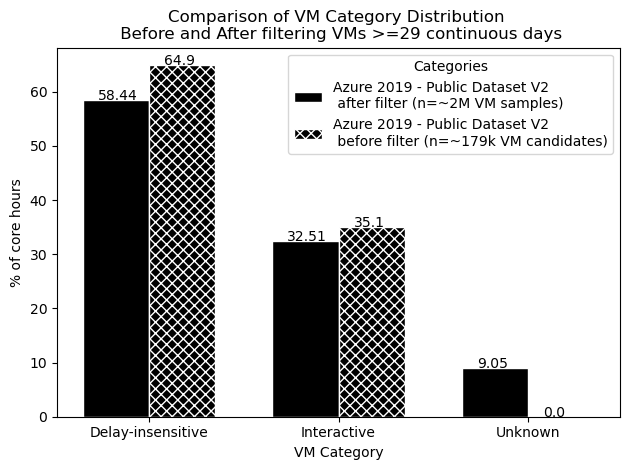

In [ ]:
dataset_after.loc[dataset_after['percentage'] == dataset_after.percentage[2], 'percentage'] = 0.0

#hatches =['..', 'xxx','..','ooo','xx']
#TraceLegend = "Azure 2019 - Public Dataset V2 - before filter"
#AzureLegend = "Azure 2019 - Public Dataset V2 - after filter"

#TraceLegend_V2 = f"Azure 2019 - Public Dataset V2 \n before filter (n=~{display_most_valuable_digits(trace_dataframe_filtered.shape[0])} VM candidates)"
#AzureLegend_V2 = f"Azure 2019 - Public Dataset V2 \n after filter (n=~{display_most_valuable_digits(trace_dataframe.shape[0])} VM samples)"

TraceLegend_V2 = f"Azure 2019 - Public Dataset V2 \n before filter (n=~2,6M VM samples) "
AzureLegend_V2 = f"Azure 2019 - Public Dataset V2 \n after filter (n=~180K VM samples)"

bar_width = 0.35
labels = dataset_before['vmcategory']
x = np.arange(len(labels))

bars_before = plt.bar(x - bar_width/2, dataset_before['percentage'], width=bar_width, label=AzureLegend_V1, color='k', edgecolor="w")
bars_after  = plt.bar(x + bar_width/2, dataset_after['percentage'],  width=bar_width, label=TraceLegend_V1, color='k', hatch=['xxx'], edgecolor="w")
#plt.bar(x - bar_width/4, dataset_before['percentage'], width=bar_width, label=AzureLegend_V2, color='b', edgecolor="w")
#plt.bar(x + bar_width/4, dataset_after['percentage'],  width=bar_width, label=TraceLegend_V2, color='b', hatch=['xxx'], edgecolor="w")

# access the bar attributes to place the text in the appropriate location
for bar in bars_before:
    yval = bar.get_height()
    plt.text(bar.get_x()+ 0.08, yval + .005, yval)

for bar in bars_after:
    yval = bar.get_height()
    plt.text(bar.get_x()+ 0.08, yval + .005, yval)



plt.xlabel('VM Category')
plt.ylabel('% of core hours')
plt.title('Comparison of VM Category Distribution \n Before and After filtering VMs >=29 continuous days')
plt.xticks(x, labels)
plt.legend(loc='best', title='Categories')

plt.tight_layout()
plt.show()

In [ ]:
dataset_after.loc[dataset_after['percentage'] == 0.5, 'percentage'] = 0
#result = pd.concat([dataset_after,dataset_before], axis=1, ignore_index=False, sort=True)
result = pd.concat([dataset_before,dataset_after], axis=1, ignore_index=False, sort=True)
del result['vmcategory']
result = result.T
result

,0,1,2
percentage,58.439585,32.510458,9.049957
percentage,64.904238,35.095762,0.000000


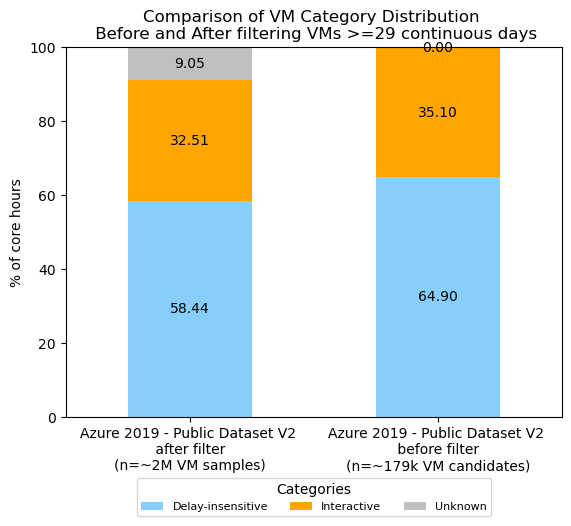

In [ ]:
#hatches =['..', 'xxx','..','ooo','xx']

ax = result.plot.bar(stacked=True,
                     #title='VM Category Distribution',
                     title='Comparison of VM Category Distribution \n Before and After filtering VMs >=29 continuous days',
                     color=['lightskyblue', 'orange', '0.75'],
                     ylim=(0, 100))

ax.set_ylabel('% of core hours')
#ax.set_xticklabels(["Azure 2019 - Public Dataset V2 \n after filter (n=250M VM samples)",
#                    "Azure 2019 - Public Dataset V2 \n before filter (n=180K VM samples)"],rotation=0)

ax.set_xticklabels([f"Azure 2019 - Public Dataset V2 \n after filter \n(n=~{display_most_valuable_digits(trace_dataframe.shape[0])} VM samples)",
                    f"Azure 2019 - Public Dataset V2 \n before filter \n(n=~{display_most_valuable_digits(trace_dataframe_filtered.shape[0])} VM candidates)"],rotation=0)

for i in range(result.shape[0]):
    for j in range(result.shape[1]):
        ax.text(i, result.iloc[i, :j+1].sum()-result.iloc[i, j]/2,
                f'{result.iloc[i, j]:.2f}',
                ha='center', va='center', color='black')

ax.legend(["Delay-insensitive", "Interactive", "Unknown"], loc='upper center', title='Categories', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=8)

plt.show()